# Crypto vs Macro context — correlazioni e regimi (Fase 1)

Confronto Tier 1 crypto (BTC/ETH/SOL/LINK/POL) con i context asset
(SPX, NDX, DXY, GOLD). Obiettivo: capire quanto crypto si muove con
"risk-on" tradizionale, e se la relazione è stabile o regime-dependent.

**Caveat di allineamento temporale**: crypto è 24/7, gli indici USA
chiudono nei weekend e festività. Le correlazioni sono calcolate su
**intersezione dei trading day** comuni (inner join sulle date dove
tutti gli asset hanno un valore di chiusura). Il rendimento crypto
"venerdì → lunedì" include il weekend, quello di SPX no — è un
allineamento imperfetto ma standard nella letteratura crypto-macro.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path("../data/raw/yahoo")
sns.set_theme(style="whitegrid")

CRYPTO = ["BTC", "ETH", "SOL", "LINK", "POL"]
INDEX = ["DXY", "SPX", "NDX"]
COMMODITY = ["GOLD"]

def load_close(symbol: str, subdir: str) -> pd.Series:
    df = pd.read_parquet(ROOT / subdir / f"{symbol}_1d.parquet").sort_index()
    # Normalize timezone to UTC midnight so date alignment works across asset classes
    s = df["close"].copy()
    s.index = pd.to_datetime(s.index).normalize().tz_localize(None)
    s.name = symbol
    return s

closes = {}
for sym in CRYPTO:
    closes[sym] = load_close(sym, "crypto")
for sym in INDEX:
    closes[sym] = load_close(sym, "index")
for sym in COMMODITY:
    closes[sym] = load_close(sym, "commodity")

prices = pd.concat(closes.values(), axis=1)
print(f"Outer-joined panel: {prices.shape[0]} dates, {prices.shape[1]} assets")
print(f"Range: {prices.index.min().date()} -> {prices.index.max().date()}")
print("NaN counts per asset:")
print(prices.isna().sum())


Outer-joined panel: 3069 dates, 9 assets
Range: 2018-01-01 -> 2026-05-27
NaN counts per asset:
BTC       0
ETH       0
SOL     830
LINK      0
POL     911
DXY     956
SPX     958
NDX     958
GOLD    957
dtype: int64


## Allineamento sulle date comuni

Calcolo i log-return su tutti gli asset, poi dropno le date dove anche
un solo asset ha NaN. Questo elimina automaticamente weekend e festività.


In [2]:
returns = np.log(prices).diff().dropna(how="any")
print(f"Common-dates panel: {returns.shape[0]} rows, {returns.shape[1]} assets")
print(f"Range: {returns.index.min().date()} -> {returns.index.max().date()}")
returns.head(3)


Common-dates panel: 974 rows, 9 assets
Range: 2020-04-14 -> 2025-03-21


,BTC,ETH,SOL,LINK,POL,DXY,SPX,NDX,GOLD
timestamp,,,,,,,,,
2020-04-14,-0.000381,0.008391,-0.161358,-0.040241,0.012828,-0.004641,0.030115,0.042229,0.006797
2020-04-15,-0.029713,-0.027726,-0.023346,-0.033895,-0.044646,0.005747,-0.022277,-0.011595,-0.016935
2020-04-16,0.069029,0.116098,0.066067,0.103047,0.083358,0.005715,0.005800,0.019121,-0.003945


## Heatmap di correlazione cross-asset

Tre cluster attesi:
- **Risk-on tradizionale**: SPX-NDX (alta), entrambi positivi con crypto
- **Dollaro forte**: DXY negativo con tutti gli altri (rischio risk-off)
- **Oro**: storicamente bassa correlazione con tutto, "safe haven"


,BTC,ETH,SOL,LINK,POL,DXY,SPX,NDX,GOLD
BTC,1.000,0.834,0.564,0.688,0.601,-0.206,0.390,0.390,0.080
ETH,0.834,1.000,0.638,0.777,0.699,-0.216,0.385,0.384,0.096
SOL,0.564,0.638,1.000,0.594,0.575,-0.191,0.316,0.314,0.038
LINK,0.688,0.777,0.594,1.000,0.671,-0.191,0.339,0.327,0.053
POL,0.601,0.699,0.575,0.671,1.000,-0.215,0.296,0.302,0.059
DXY,-0.206,-0.216,-0.191,-0.191,-0.215,1.000,-0.319,-0.287,-0.415
SPX,0.390,0.385,0.316,0.339,0.296,-0.319,1.000,0.934,0.086
NDX,0.390,0.384,0.314,0.327,0.302,-0.287,0.934,1.000,0.098
GOLD,0.080,0.096,0.038,0.053,0.059,-0.415,0.086,0.098,1.000


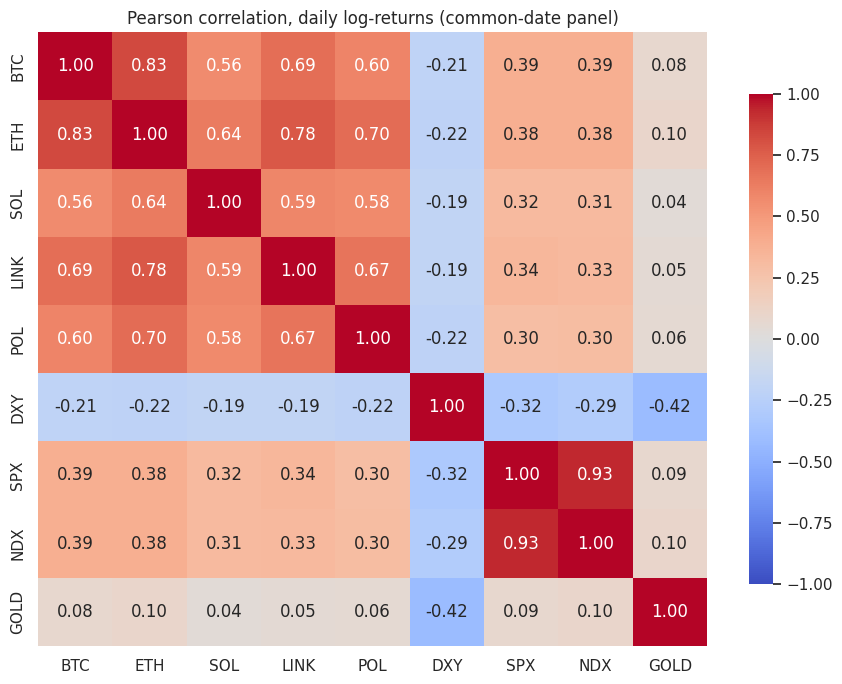

In [3]:
corr = returns.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Pearson correlation, daily log-returns (common-date panel)")
plt.tight_layout()
corr.round(3)


## Correlazione rolling BTC vs ogni context asset

Le correlazioni medie nascondono i regimi. Una rolling-90d fa vedere se
e quando il legame crypto-macro è cambiato (es. post-COVID, ciclo
2022 bear, ETF approval 2024).


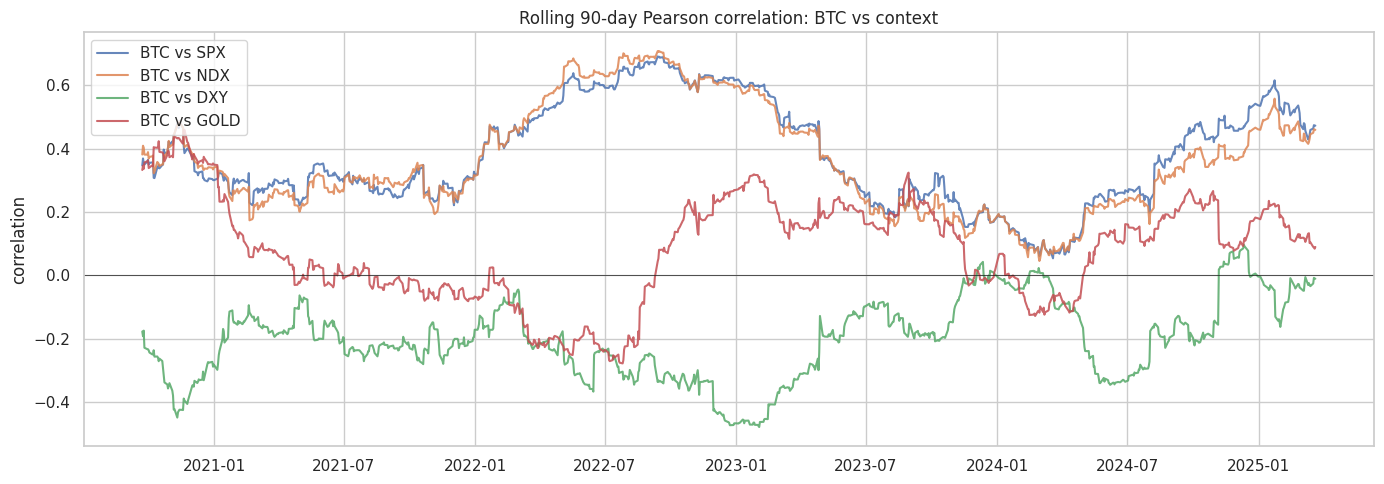

In [4]:
WINDOW = 90

fig, ax = plt.subplots(figsize=(14, 5))
for sym in ["SPX", "NDX", "DXY", "GOLD"]:
    rc = returns["BTC"].rolling(WINDOW).corr(returns[sym])
    ax.plot(rc.index, rc.values, label=f"BTC vs {sym}", alpha=0.85)
ax.axhline(0, color="k", lw=0.5)
ax.set_title(f"Rolling {WINDOW}-day Pearson correlation: BTC vs context")
ax.set_ylabel("correlation")
ax.legend(loc="upper left")
plt.tight_layout()


## Le correlazioni sono stabili?

Misura la **deviazione standard della rolling-90d** come proxy di
instabilità: una correlazione "stabile" ha std bassa, una
regime-dependent ha std alta.


In [5]:
stab_rows = []
for crypto_sym in CRYPTO:
    for macro_sym in ["SPX", "NDX", "DXY", "GOLD"]:
        rc = returns[crypto_sym].rolling(WINDOW).corr(returns[macro_sym]).dropna()
        stab_rows.append({
            "crypto": crypto_sym,
            "macro": macro_sym,
            "mean_corr": rc.mean(),
            "std_corr": rc.std(),
            "min_corr": rc.min(),
            "max_corr": rc.max(),
        })
stability = pd.DataFrame(stab_rows)
print("Mean and std of rolling 90d correlation (crypto x macro):")
print()
print("--- Mean ---")
print(stability.pivot(index="crypto", columns="macro", values="mean_corr").round(2))
print()
print("--- Std (instability) ---")
print(stability.pivot(index="crypto", columns="macro", values="std_corr").round(2))


Mean and std of rolling 90d correlation (crypto x macro):

--- Mean ---
macro    DXY  GOLD   NDX   SPX
crypto                        
BTC    -0.20  0.08  0.36  0.38
ETH    -0.22  0.10  0.36  0.37
LINK   -0.20  0.05  0.32  0.34
POL    -0.25  0.07  0.32  0.33
SOL    -0.21  0.04  0.31  0.33

--- Std (instability) ---
macro    DXY  GOLD   NDX   SPX
crypto                        
BTC     0.12  0.16  0.17  0.16
ETH     0.11  0.13  0.16  0.16
LINK    0.11  0.13  0.17  0.15
POL     0.10  0.12  0.15  0.13
SOL     0.09  0.13  0.14  0.13


## Distribuzione delle correlazioni rolling: BTC vs SPX

Per leggere se il regime è bimodale (alterna 'high corr' / 'low corr') o
unimodale (oscilla intorno a una media).


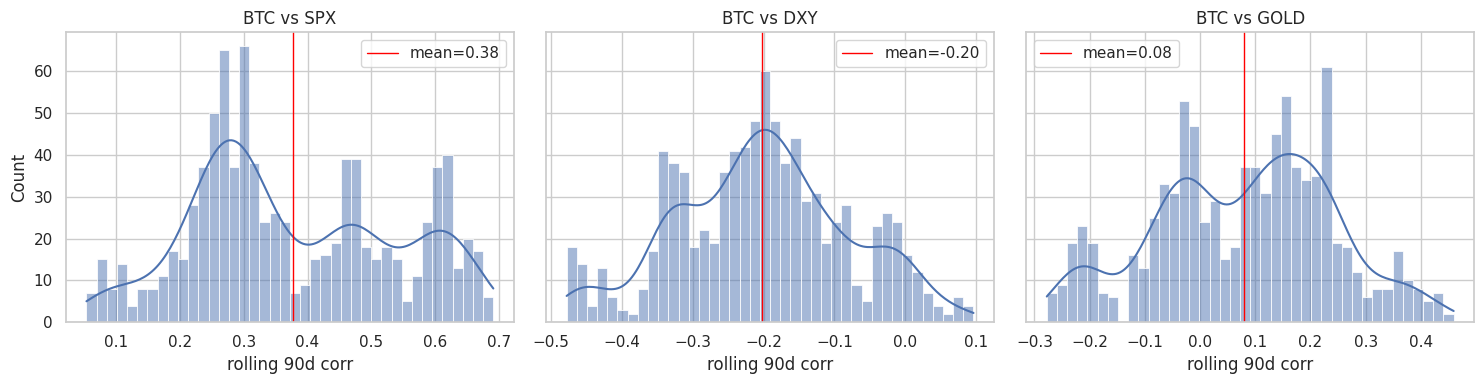

In [6]:
rc_btc_spx = returns["BTC"].rolling(WINDOW).corr(returns["SPX"]).dropna()
rc_btc_dxy = returns["BTC"].rolling(WINDOW).corr(returns["DXY"]).dropna()
rc_btc_gold = returns["BTC"].rolling(WINDOW).corr(returns["GOLD"]).dropna()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (label, s) in zip(axes, [("BTC vs SPX", rc_btc_spx), ("BTC vs DXY", rc_btc_dxy), ("BTC vs GOLD", rc_btc_gold)]):
    sns.histplot(s, bins=40, kde=True, ax=ax)
    ax.axvline(s.mean(), color="red", lw=1, label=f"mean={s.mean():.2f}")
    ax.set_title(label)
    ax.set_xlabel("rolling 90d corr")
    ax.legend()
plt.tight_layout()


## Note metodologiche e prossimi passi

- L'inner-join sui trading day include il "weekend gap" del crypto come
  parte del lunedì: per analisi più rigorose serve costruire un return
  crypto "venerdì-chiusa → venerdì-chiusa" allineato alla cadenza dei
  mercati tradizionali
- Le correlazioni Pearson assumono linearità: per crypto, dove gli
  eventi estremi dominano, vale la pena verificare con rank correlation
  (Spearman) e tail dependence (copula)
- I regimi vanno marcati con eventi noti (COVID-shock 2020-03, FTX
  2022-11, SVB 2023-03, ETF 2024-01) per leggere la dinamica della
  correlazione in contesto
- Trasferire questa analisi a livello mensile per smussare il rumore
  e cercare relazioni di medio periodo
